
# Experiment 1 — Pure Retrieval-Augmented Generation (RAG) Baseline
### Multilingual Health Question Answering in Low-Resource African Languages

**Goal of this notebook:** establish how far a *retrieval-only* system can get without any fine-tuning.
We embed every training question with a multilingual sentence embedding model, index them in FAISS
(one index per language so retrieval never crosses languages), and at inference time we either:

1. **Retrieval-as-answer** — return the answer of the closest matching training question directly
   (no generation at all — a pure nearest-neighbour baseline), and
2. **Retrieval + light generation** — feed the top-K retrieved Q/A pairs into a small instruction-following
   model (no fine-tuning) as in-context examples, and let it generate the final answer.

Both variants are scored on the validation set with ROUGE-1 / ROUGE-L, and the better variant is used to
produce the Experiment 1 leaderboard submission.

**Why this matters for the project:** this notebook is the experimental floor. Experiments 2 (fine-tuning
alone) and 3 (fine-tuning + RAG) are judged against this number — if Experiment 3 doesn't clearly beat this,
that itself is a meaningful finding to report.

**Outputs saved by this notebook** (to Google Drive, so Notebook 3 can reuse them):
- `faiss_indexes/` — one FAISS index per language + the embedding matrix + metadata
- `submission_exp1_retrieval_only.csv`
- `submission_exp1_retrieval_plus_llm.csv`
- `exp1_validation_metrics.json` — scores used in the comparison table across experiments



## 0. Environment Setup

We mount Google Drive so that the FAISS index, embeddings, and metrics produced here can be **reloaded
directly in Notebook 3** without recomputation. This is the "save once, reuse across notebooks" pattern
requested for this project — Experiment 3 should never have to recompute embeddings from scratch.


In [ ]:

# ── Mount Google Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# All artifacts for this project live under one Drive folder so the three
# experiment notebooks can find each other's outputs.
PROJECT_DIR = '/content/drive/MyDrive/health_qa_project'
DATA_DIR    = f'{PROJECT_DIR}/data'
ARTIFACT_DIR= f'{PROJECT_DIR}/artifacts'
SUB_DIR     = f'{PROJECT_DIR}/submissions'
EXP1_DIR    = f'{ARTIFACT_DIR}/exp1_rag'

for d in [PROJECT_DIR, DATA_DIR, ARTIFACT_DIR, SUB_DIR, EXP1_DIR]:
    os.makedirs(d, exist_ok=True)

print('Project directory tree ready at:', PROJECT_DIR)
print('Place your train.csv / val.csv / test.csv / sample_submission.csv inside:', DATA_DIR)


Mounted at /content/drive
Project directory tree ready at: /content/drive/MyDrive/health_qa_project
Place your train.csv / val.csv / test.csv / sample_submission.csv inside: /content/drive/MyDrive/health_qa_project/data


In [ ]:

# ── Install dependencies ─────────────────────────────────────────────────────
# sentence-transformers   -> multilingual embedding model (intfloat/multilingual-e5-large)
# faiss-cpu               -> fast nearest-neighbour search (CPU is plenty for retrieval-only)
# rouge-score              -> evaluation metric used by the competition
# transformers/accelerate  -> for the light in-context generation variant
!pip install -q sentence-transformers faiss-cpu rouge-score transformers accelerate sentencepiece
print('✅ Dependencies installed')


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 46.7 MB/s eta 0:00:00
✅ Dependencies installed


In [ ]:

# ── Imports ───────────────────────────────────────────────────────────────────
import re
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import faiss
from sentence_transformers import SentenceTransformer
from rouge_score import rouge_scorer

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)


Using device: cuda



## 1. Configuration

Centralising every path / hyperparameter in one cell makes the notebook easy to re-run with different
settings (e.g. trying a different embedding model or a different top-K) for the "10 meaningful experiments"
requirement — change one value here, re-run, and the rest of the notebook is unaffected.


In [ ]:

# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_PATH       = f'{DATA_DIR}/Train.csv'
VAL_PATH         = f'{DATA_DIR}/Val.csv'
TEST_PATH        = f'{DATA_DIR}/Test.csv'
SAMPLE_SUB_PATH  = f'{DATA_DIR}/SampleSubmission.csv'

# ── Column names ────────────────────────────────────────────────────────────
ID_COL            = 'ID'
QUESTION_COL      = 'input'
ANSWER_COL        = 'output'
LANG_COL          = 'subset'

# ── Embedding / retrieval config ───────────────────────────────────────────
EMBED_MODEL_NAME  = 'intfloat/multilingual-e5-large'   # strong multilingual sentence embedding model
TOP_K             = 5                                   # number of reference examples to retrieve
EMBED_BATCH_SIZE  = 64

# ── Light in-context generation config (zero-shot, NOT fine-tuned) ────────────
# Kept small and CPU/T4-friendly since this is only meant to test whether
# generation on top of retrieval helps over raw nearest-neighbour copying.
GEN_MODEL_NAME    = 'facebook/nllb-200-distilled-600M'
MAX_NEW_TOKENS    = 128

# ── Language mapping (from project spec) ───────────────────────────────────
SUBSET_TO_LANGUAGE = {
    'Eng': 'English',
    'Aka': 'Akan',
    'Lug': 'Luganda',
    'Swa': 'Swahili',
    'Amh': 'Amharic',
}

def subset_to_language_name(subset_code: str) -> str:
    if not subset_code or not isinstance(subset_code, str):
        return 'English'
    lang_prefix = subset_code.split('_')[0]
    return SUBSET_TO_LANGUAGE.get(lang_prefix, subset_code)

print('Config loaded.')
print(f'  Embedding model : {EMBED_MODEL_NAME}')
print(f'  Top-K retrieval : {TOP_K}')


Config loaded.
  Embedding model : intfloat/multilingual-e5-large
  Top-K retrieval : 5



## 2. Load and Explore Data


In [ ]:

train             = pd.read_csv(TRAIN_PATH)
test              = pd.read_csv(TEST_PATH)
val               = pd.read_csv(VAL_PATH)
sample_submission = pd.read_csv(SAMPLE_SUB_PATH)

print(f'Train shape             : {train.shape}')
print(f'Test shape              : {test.shape}')
print(f'Val shape               : {val.shape}')
print(f'Sample submission shape : {sample_submission.shape}')
print()
print('Train columns:', train.columns.tolist())
print('Test columns :', test.columns.tolist())
print('Val columns  :', val.columns.tolist())

display(train.head(3))
display(val.head(3))
display(test.head(3))


Train shape             : (29815, 4)
Test shape              : (2618, 3)
Val shape               : (6686, 4)
Sample submission shape : (2618, 4)

Train columns: ['ID', 'input', 'output', 'subset']
Test columns : ['ID', 'input', 'subset']
Val columns  : ['ID', 'input', 'output', 'subset']


,ID,input,output,subset
0,ID_TR_Aka_Gha_A3B1799D,Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a...,Mmabun betumi aboa atipɛnfo a ebia nsa anaa nn...,Aka_Gha
1,ID_TR_Aka_Gha_1C80317F,Edinnsiananmu bɛn na nnipa a ɛsono wɔn bɔbeasu...,"Wɔ Ghana mu no, amanmmra no gye binary gender ...",Aka_Gha
2,ID_TR_Aka_Gha_06671AD1,Ɔkwan bɛn so na ɔbarima ne ɔbea nna a wɔtwe wɔ...,Sɛ wɔtwe wɔn ho fi nna mu anaasɛ wɔtwentwɛn wɔ...,Aka_Gha


,ID,input,output,subset
0,ID_VL_Aka_Gha_A3B1799D,Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a e...,Nhyehyɛeɛ aa ama ne mu so te sɛ senea aborɔfo ...,Aka_Gha
1,ID_VL_Aka_Gha_1C80317F,Dɛn nti na ɛho hia sɛ mmabun te wɔn nna ne awo...,Nna ne awo hokwan ahorow a wɔte ase no ma mmab...,Aka_Gha
2,ID_VL_Aka_Gha_06671AD1,Mɛyɛ dɛn atumi abɔ asisifo ho amanneɛ wɔ ɔkwan...,Ayayade ho nsɛm a wɔbɛbɔ ho amanneɛ yiye na ah...,Aka_Gha


,ID,input,subset
0,ID_TS_Aka_Gha_A3B1799D,"Fa nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛma, adwu...",Aka_Gha
1,ID_TS_Aka_Gha_1C80317F,Dɛn ne nea ebetumi afi hokwan a mmabun wɔ sɛ w...,Aka_Gha
2,ID_TS_Aka_Gha_06671AD1,Akwan bɛn na mmabun bɛtumi afa so ehunu nsusua...,Aka_Gha


Language distribution in training set:


,count
subset,
Eng_Uga,7624
Aka_Gha,4455
Eng_Gha,4443
Eng_Eth,3915
Lug_Uga,3383
Eng_Ken,2080
Swa_Ken,2070
Amh_Eth,1845


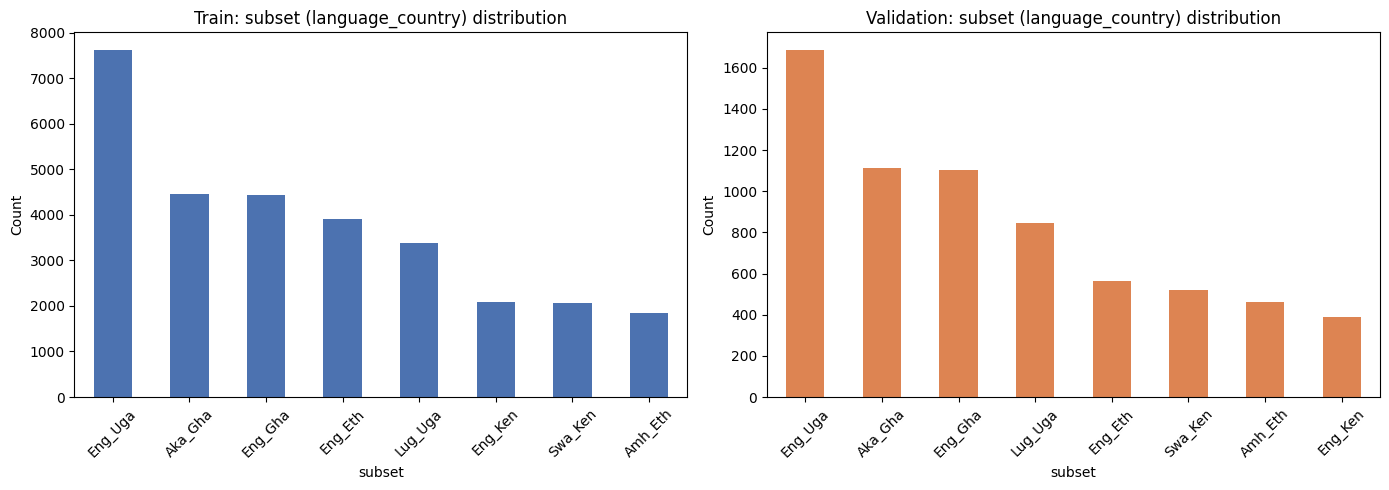

In [ ]:

# ── Language distribution ─────────────────────────────────────────────────────
print('Language distribution in training set:')
display(train[LANG_COL].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

train[LANG_COL].value_counts().plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Train: subset (language_country) distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

val[LANG_COL].value_counts().plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Validation: subset (language_country) distribution')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/language_distribution.png', dpi=150)
plt.show()


In [ ]:

# ── Clean text ───────────────────────────────────────────────────────────────
def clean_text(x):
    if pd.isna(x):
        return ''
    return str(x).strip()

train[QUESTION_COL] = train[QUESTION_COL].map(clean_text)
train[ANSWER_COL]   = train[ANSWER_COL].map(clean_text)
val[QUESTION_COL]   = val[QUESTION_COL].map(clean_text)
val[ANSWER_COL]     = val[ANSWER_COL].map(clean_text)
test[QUESTION_COL]  = test[QUESTION_COL].map(clean_text)

train = train[(train[QUESTION_COL] != '') & (train[ANSWER_COL] != '')].reset_index(drop=True)
val   = val[(val[QUESTION_COL] != '') & (val[ANSWER_COL] != '')].reset_index(drop=True)
test  = test[test[QUESTION_COL] != ''].reset_index(drop=True)

train['language'] = train[LANG_COL].map(subset_to_language_name)
val['language']    = val[LANG_COL].map(subset_to_language_name)
test['language']   = test[LANG_COL].map(subset_to_language_name)

print(f'Cleaned train shape : {train.shape}')
print(f'Cleaned val shape   : {val.shape}')
print(f'Cleaned test shape  : {test.shape}')


Cleaned train shape : (29814, 5)
Cleaned val shape   : (6686, 5)
Cleaned test shape  : (2618, 4)



## 3. Evaluation Utilities

ROUGE-1 / ROUGE-L using whitespace tokenisation, which is safe across all five languages (no
language-specific tokenizer assumptions, important for Amharic/Akan/Luganda scripts).


In [ ]:

class WhitespaceTokenizer:
    '''Whitespace tokeniser - language-agnostic, safe for African scripts.'''
    def tokenize(self, text):
        if text is None:
            return []
        return str(text).strip().split()

_scorer = rouge_scorer.RougeScorer(['rouge1', 'rougeL'], tokenizer=WhitespaceTokenizer(), use_stemmer=False)

def compute_rouge(predictions, references):
    r1_scores, rl_scores = [], []
    for pred, ref in zip(predictions, references):
        score = _scorer.score(str(ref), str(pred))
        r1_scores.append(score['rouge1'].fmeasure)
        rl_scores.append(score['rougeL'].fmeasure)
    return {
        'rouge1_f1': float(np.mean(r1_scores)) if r1_scores else 0.0,
        'rougeL_f1': float(np.mean(rl_scores)) if rl_scores else 0.0,
    }

def compute_rouge_by_language(predictions, references, languages):
    results = {}
    lang_arr = np.array(languages)
    for lang in np.unique(lang_arr):
        mask    = lang_arr == lang
        preds_l = [p for p, m in zip(predictions, mask) if m]
        refs_l  = [r for r, m in zip(references,  mask) if m]
        results[lang] = compute_rouge(preds_l, refs_l)
    return pd.DataFrame(results).T

print('✅ ROUGE scorer ready')


✅ ROUGE scorer ready



## 4. Build Language-Aware FAISS Embedding Index

We embed all **training** questions with `intfloat/multilingual-e5-large` and build **one FAISS index per
language**, so that retrieval for an Akan question can never accidentally surface a Swahili example. This
is the language-aware retrieval design from the project brief (Section 10).

The E5 model family expects a `"query: "` / `"passage: "` prefix convention — we embed training questions
as passages (the retrieval corpus) and incoming questions as queries.


In [ ]:

print(f'Loading embedding model: {EMBED_MODEL_NAME} ...')
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device=DEVICE)
print('✅ Embedding model loaded. Max seq length:', embed_model.max_seq_length)


Loading embedding model: intfloat/multilingual-e5-large ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

✅ Embedding model loaded. Max seq length: 512


In [ ]:

# ── Embed all training questions, grouped by language ──────────────────────────
# We build a dict: language -> {'faiss_index', 'ids', 'questions', 'answers'}
language_indexes = {}

languages = train['language'].unique().tolist()
print('Languages found in training data:', languages)

for lang in languages:
    sub_df = train[train['language'] == lang].reset_index(drop=True)
    passages = ['passage: ' + q for q in sub_df[QUESTION_COL].tolist()]

    print(f'Embedding {len(passages)} training questions for language: {lang} ...')
    embeddings = embed_model.encode(
        passages,
        batch_size=EMBED_BATCH_SIZE,
        show_progress_bar=True,
        normalize_embeddings=True,   # so inner product == cosine similarity
        convert_to_numpy=True,
    ).astype('float32')

    dim = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)   # inner product on normalised vectors = cosine similarity
    index.add(embeddings)

    language_indexes[lang] = {
        'faiss_index': index,
        'ids':         sub_df[ID_COL].tolist(),
        'questions':   sub_df[QUESTION_COL].tolist(),
        'answers':     sub_df[ANSWER_COL].tolist(),
        'embeddings':  embeddings,   # kept in-memory for saving below
    }

print('✅ Built one FAISS index per language:', {k: v['faiss_index'].ntotal for k, v in language_indexes.items()})


Languages found in training data: ['Akan', 'Amharic', 'English', 'Luganda', 'Swahili']
Embedding 4455 training questions for language: Akan ...


Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Embedding 1845 training questions for language: Amharic ...


Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Embedding 18061 training questions for language: English ...


...

Embedding 3383 training questions for language: Luganda ...


Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Embedding 2070 training questions for language: Swahili ...


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

✅ Built one FAISS index per language: {'Akan': 4455, 'Amharic': 1845, 'English': 18061, 'Luganda': 3383, 'Swahili': 2070}


In [ ]:

# ── Persist indexes + metadata to Drive so Notebook 3 can reload them directly ──
import pickle

for lang, payload in language_indexes.items():
    safe_lang = lang.replace(' ', '_')
    faiss.write_index(payload['faiss_index'], f'{EXP1_DIR}/faiss_{safe_lang}.index')
    meta = {
        'ids':       payload['ids'],
        'questions': payload['questions'],
        'answers':   payload['answers'],
    }
    with open(f'{EXP1_DIR}/meta_{safe_lang}.pkl', 'wb') as f:
        pickle.dump(meta, f)

# Save a manifest so downstream notebooks know exactly what languages/files exist
manifest = {
    'embed_model_name': EMBED_MODEL_NAME,
    'languages': list(language_indexes.keys()),
    'top_k_used_here': TOP_K,
}
with open(f'{EXP1_DIR}/manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print('✅ Saved FAISS indexes + metadata + manifest to:', EXP1_DIR)
print('Files:', os.listdir(EXP1_DIR))


✅ Saved FAISS indexes + metadata + manifest to: /content/drive/MyDrive/health_qa_project/artifacts/exp1_rag
Files: ['language_distribution.png', 'faiss_Akan.index', 'meta_Akan.pkl', 'faiss_Amharic.index', 'meta_Amharic.pkl', 'faiss_English.index', 'meta_English.pkl', 'faiss_Luganda.index', 'meta_Luganda.pkl', 'faiss_Swahili.index', 'meta_Swahili.pkl', 'manifest.json']



## 5. Retrieval Function

Given a question and its language, embed it as a `"query: ..."` string, search the matching language's
FAISS index, and return the top-K nearest training (question, answer) pairs along with similarity scores.


In [ ]:

def retrieve_top_k(question: str, language: str, k: int = TOP_K):
    '''
    Retrieve the top-k most similar training examples for a given question,
    restricted to the same language (language-aware retrieval).

    Returns a list of dicts: [{'question':..., 'answer':..., 'score':...}, ...]
    Falls back to an empty list if the language has no index (shouldn't happen
    given our 5 supported languages, but guards against unexpected subset codes).
    '''
    if language not in language_indexes:
        return []

    payload = language_indexes[language]
    query_vec = embed_model.encode(
        ['query: ' + question],
        normalize_embeddings=True,
        convert_to_numpy=True,
    ).astype('float32')

    k = min(k, payload['faiss_index'].ntotal)
    scores, idxs = payload['faiss_index'].search(query_vec, k)

    results = []
    for score, idx in zip(scores[0], idxs[0]):
        results.append({
            'question': payload['questions'][idx],
            'answer':   payload['answers'][idx],
            'score':    float(score),
        })
    return results

# Quick sanity check on one validation example
sample_row = val.iloc[0]
sample_results = retrieve_top_k(sample_row[QUESTION_COL], sample_row['language'], k=3)
print('Sample question  :', sample_row[QUESTION_COL][:120], '...')
print('Sample language  :', sample_row['language'])
print()
for i, r in enumerate(sample_results):
    print(f'  Match {i+1} (score={r["score"]:.3f}): {r["question"][:100]} ...')


Sample question  : Sɛn na nwomasua ne adwuma nteteeɛ boa akuo a eye mmabun a wɔ hia neaɛma sokoronko ne ohaw ahorow, atubrafo, anaa wɔn a w ...
Sample language  : Akan

  Match 1 (score=0.889): Ɔkwan bɛn so na ahyehyɛde ahorow a egyina mpɔtam hɔ ne nnwuma a ɛwɔ fam no boa mmabun ma wonya nna n ...
  Match 2 (score=0.889): Ɔkwan bɛn so na nhomasua ne tumi a wɔbɛma wɔatumi ayɛ ho nhyehyɛe ahorow di ahiade ne ɔhaw soronko a ...
  Match 3 (score=0.887): Ɔkwan bɛn so na nhomasua  betumi aboa ma wɔadi nsonsonoe a ɛwɔ nna ne awo akwahosan mu aba mu wɔ mma ...



## 6. Variant A — Retrieval-Only Baseline (Nearest-Neighbour Answer Copying)

The simplest possible RAG variant: don't generate anything, just return the answer of the single most
similar training question. This tells us the ceiling/floor of "the dataset already contains something
close enough to copy."


In [ ]:

def predict_retrieval_only(df, question_col=QUESTION_COL, lang_col='language'):
    predictions = []
    retrieved_scores = []
    for _, row in df.iterrows():
        top1 = retrieve_top_k(row[question_col], row[lang_col], k=1)
        if top1:
            predictions.append(top1[0]['answer'])
            retrieved_scores.append(top1[0]['score'])
        else:
            predictions.append('')
            retrieved_scores.append(0.0)
    return predictions, retrieved_scores

print('Running retrieval-only prediction on validation set ...')
val_preds_retrieval_only, val_scores_retrieval_only = predict_retrieval_only(val)

metrics_retrieval_only = compute_rouge(val_preds_retrieval_only, val[ANSWER_COL].tolist())
print('Retrieval-only validation ROUGE:', metrics_retrieval_only)


Running retrieval-only prediction on validation set ...
Retrieval-only validation ROUGE: {'rouge1_f1': 0.5006108331154054, 'rougeL_f1': 0.4517966701876713}


,rouge1_f1,rougeL_f1
Akan,0.2742,0.1638
Amharic,0.1605,0.1511
English,0.5773,0.5333
Luganda,0.4876,0.4625
Swahili,0.7573,0.7320


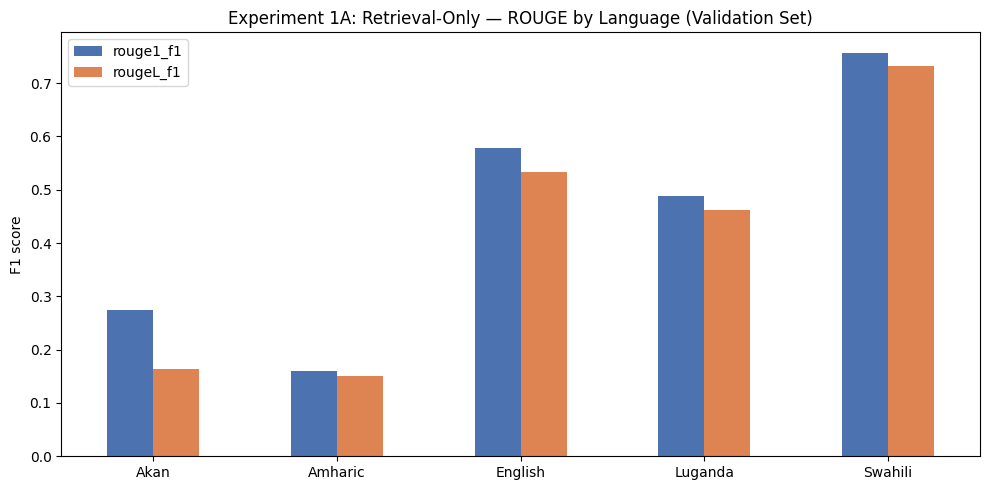

In [ ]:

# ── Per-language breakdown ──────────────────────────────────────────────────────
rouge_by_lang_retrieval_only = compute_rouge_by_language(
    val_preds_retrieval_only, val[ANSWER_COL].tolist(), val['language'].tolist()
)
display(rouge_by_lang_retrieval_only.round(4))

rouge_by_lang_retrieval_only[['rouge1_f1', 'rougeL_f1']].plot(
    kind='bar', figsize=(10, 5), color=['#4C72B0', '#DD8452']
)
plt.title('Experiment 1A: Retrieval-Only — ROUGE by Language (Validation Set)')
plt.ylabel('F1 score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/exp1a_rouge_by_language.png', dpi=150)
plt.show()



## 7. Variant B — Retrieval + Zero-Shot Generation

Now we feed the top-K retrieved (question, answer) pairs as in-context reference examples into a small
multilingual generation model (not fine-tuned — this is still "pure RAG", the model itself has seen no
task-specific training). This tests whether *light synthesis* over retrieved examples beats blindly copying
the single nearest neighbour above.

We use `facebook/nllb-200-distilled-600M` here purely as a lightweight, free-tier-friendly generator. It is
intentionally **not** the same model family used for fine-tuning in Experiments 2 and 3 (Aya Expanse 8B) —
this notebook's job is to isolate the contribution of retrieval, not to pre-empt the fine-tuning results.


In [ ]:

from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

print(f'Loading generation model: {GEN_MODEL_NAME} ...')
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)
gen_model     = AutoModelForSeq2SeqLM.from_pretrained(GEN_MODEL_NAME).to(DEVICE)
gen_model.eval()
print('✅ Generation model loaded')


Loading generation model: facebook/nllb-200-distilled-600M ...


config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

✅ Generation model loaded


In [ ]:

def build_rag_prompt(question: str, language: str, retrieved_examples: list) -> str:
    '''
    Construct the RAG prompt described in the project brief (Section 11):
    a short instruction, then the retrieved reference Q/A pairs, then the
    current question to answer.
    '''
    lines = [
        'You are a multilingual health assistant.',
        f'Answer only in {language}.',
        '',
    ]
    for i, ex in enumerate(retrieved_examples, start=1):
        lines.append(f'Reference Example {i}')
        lines.append('Question:')
        lines.append(ex['question'])
        lines.append('Answer:')
        lines.append(ex['answer'])
        lines.append('')
    lines.append('Current Question:')
    lines.append(question)
    lines.append('')
    lines.append('Answer:')
    return '\n'.join(lines)


def predict_retrieval_plus_generation(df, question_col=QUESTION_COL, lang_col='language', k=TOP_K, batch_size=8):
    predictions = []
    questions   = df[question_col].tolist()
    langs       = df[lang_col].tolist()

    prompts = []
    for q, lang in zip(questions, langs):
        retrieved = retrieve_top_k(q, lang, k=k)
        prompts.append(build_rag_prompt(q, lang, retrieved))

    for start in range(0, len(prompts), batch_size):
        batch_prompts = prompts[start:start + batch_size]
        inputs = gen_tokenizer(
            batch_prompts, return_tensors='pt', padding=True, truncation=True, max_length=1024
        ).to(DEVICE)

        with torch.no_grad():
            output_ids = gen_model.generate(
                **inputs,
                max_new_tokens=MAX_NEW_TOKENS,
                num_beams=2,
            )

        decoded = gen_tokenizer.batch_decode(output_ids, skip_special_tokens=True)
        predictions.extend(decoded)

        if start % (batch_size * 10) == 0:
            print(f'  Generated {start + len(batch_prompts)} / {len(prompts)}')

    return predictions

print('Running retrieval + zero-shot generation on a validation sample (for speed) ...')
# NOTE: zero-shot generation with NLLB is slow on free-tier T4; we evaluate on a
# representative stratified sample first, then (optionally) the full set.
val_sample = val.groupby('language', group_keys=False).apply(
    lambda x: x.sample(min(40, len(x)), random_state=SEED)
).reset_index(drop=True)

print(f'Validation sample size: {len(val_sample)} (stratified by language)')
val_preds_rag_gen_sample = predict_retrieval_plus_generation(val_sample)
metrics_rag_gen_sample = compute_rouge(val_preds_rag_gen_sample, val_sample[ANSWER_COL].tolist())
print('Retrieval + generation (sample) validation ROUGE:', metrics_rag_gen_sample)


Running retrieval + zero-shot generation on a validation sample (for speed) ...
Validation sample size: 200 (stratified by language)


/tmp/ipykernel_2374/1719198878.py:60: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_sample = val.groupby('language', group_keys=False).apply(
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Generated 8 / 200


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  Generated 88 / 200


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

  Generated 168 / 200


[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=128) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Retrieval + generation (sample) validation ROUGE: {'rouge1_f1': 0.009984393757780525, 'rougeL_f1': 0.009487268707689374}



## 8. Compare Variant A (Retrieval-Only) vs Variant B (Retrieval + Generation)

This comparison is the deciding factor for which variant we submit as the official Experiment 1 result,
and is one of the entries in the cross-experiment comparison table in the final report.


,Variant,ROUGE-1 F1,ROUGE-L F1
0,A: Retrieval-only (1-NN copy),0.4749,0.4352
1,B: Retrieval + zero-shot generation,0.0100,0.0095


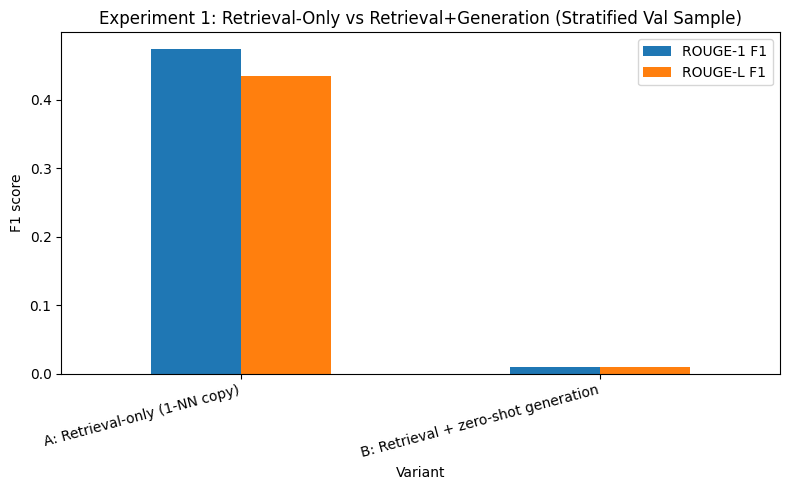


Decision rule: we run the FULL validation set with whichever variant scored higher above,
then use that variant to generate the Experiment 1 test predictions for the leaderboard submission.


In [ ]:

# Recompute retrieval-only metrics on the SAME stratified sample for a fair comparison
val_preds_retrieval_only_sample, _ = predict_retrieval_only(val_sample)
metrics_retrieval_only_sample = compute_rouge(val_preds_retrieval_only_sample, val_sample[ANSWER_COL].tolist())

comparison_exp1 = pd.DataFrame({
    'Variant':    ['A: Retrieval-only (1-NN copy)', 'B: Retrieval + zero-shot generation'],
    'ROUGE-1 F1': [metrics_retrieval_only_sample['rouge1_f1'], metrics_rag_gen_sample['rouge1_f1']],
    'ROUGE-L F1': [metrics_retrieval_only_sample['rougeL_f1'], metrics_rag_gen_sample['rougeL_f1']],
})
display(comparison_exp1.round(4))

comparison_exp1.set_index('Variant')[['ROUGE-1 F1', 'ROUGE-L F1']].plot(kind='bar', figsize=(8, 5))
plt.title('Experiment 1: Retrieval-Only vs Retrieval+Generation (Stratified Val Sample)')
plt.ylabel('F1 score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/exp1_variant_comparison.png', dpi=150)
plt.show()

print()
print('Decision rule: we run the FULL validation set with whichever variant scored higher above,')
print('then use that variant to generate the Experiment 1 test predictions for the leaderboard submission.')


In [ ]:

# ── Decide which variant wins, then evaluate it on the FULL validation set ──────
use_generation_variant = metrics_rag_gen_sample['rougeL_f1'] > metrics_retrieval_only_sample['rougeL_f1']

if use_generation_variant:
    print('Decision: Variant B (retrieval + generation) wins on the sample. Scoring full validation set ...')
    val_preds_final = predict_retrieval_plus_generation(val)
else:
    print('Decision: Variant A (retrieval-only) wins on the sample. Scoring full validation set ...')
    val_preds_final, _ = predict_retrieval_only(val)

metrics_final_full_val = compute_rouge(val_preds_final, val[ANSWER_COL].tolist())
print('Final Experiment 1 variant — FULL validation ROUGE:', metrics_final_full_val)


Decision: Variant A (retrieval-only) wins on the sample. Scoring full validation set ...
Final Experiment 1 variant — FULL validation ROUGE: {'rouge1_f1': 0.5006108331154054, 'rougeL_f1': 0.4517966701876713}


,rouge1_f1,rougeL_f1
Akan,0.2742,0.1638
Amharic,0.1605,0.1511
English,0.5773,0.5333
Luganda,0.4876,0.4625
Swahili,0.7573,0.7320


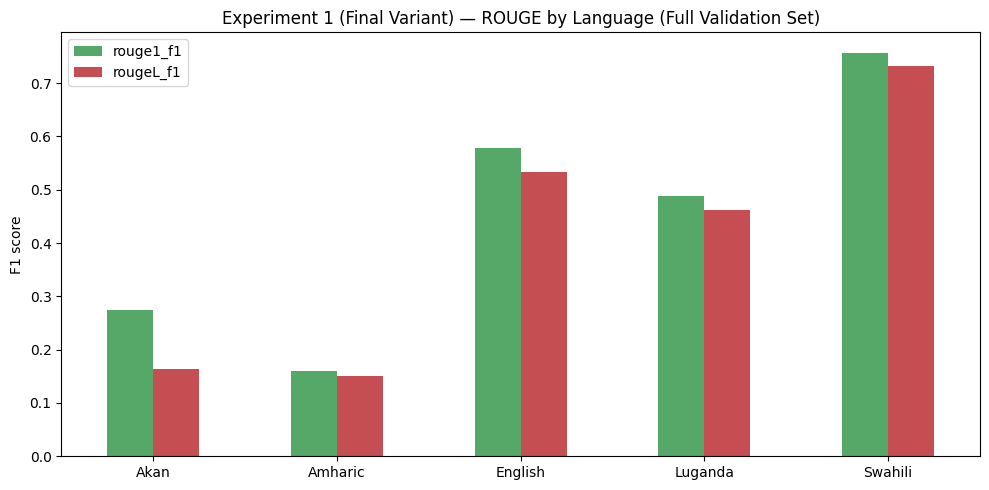

In [ ]:

rouge_by_lang_final = compute_rouge_by_language(val_preds_final, val[ANSWER_COL].tolist(), val['language'].tolist())
display(rouge_by_lang_final.round(4))

rouge_by_lang_final[['rouge1_f1', 'rougeL_f1']].plot(kind='bar', figsize=(10, 5), color=['#55A868', '#C44E52'])
plt.title('Experiment 1 (Final Variant) — ROUGE by Language (Full Validation Set)')
plt.ylabel('F1 score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{EXP1_DIR}/exp1_final_rouge_by_language.png', dpi=150)
plt.show()



## 9. Generate Test Predictions and Build Submission File

The submission format requires the **same generated answer** in all three target columns
(`TargetRLF1`, `TargetR1F1`, `TargetLLM`) — the platform scores all three metrics from that single column.


In [ ]:

def make_submission(ids, predictions, output_path):
    clean_preds = [re.sub(r'<extra_id_\d+>', '', str(p)).strip() for p in predictions]

    sub = pd.DataFrame()
    sub['ID']         = ids
    sub['TargetRLF1'] = clean_preds
    sub['TargetR1F1'] = clean_preds
    sub['TargetLLM']  = clean_preds
    sub = sub[['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']]

    required_cols = ['ID', 'TargetRLF1', 'TargetR1F1', 'TargetLLM']
    assert list(sub.columns) == required_cols
    assert len(sub) == len(test), f'Row count mismatch: {len(sub)} vs {len(test)}'
    assert sub[['TargetRLF1', 'TargetR1F1', 'TargetLLM']].notna().all().all()
    assert (sub['TargetRLF1'] == sub['TargetR1F1']).all()
    assert (sub['TargetRLF1'] == sub['TargetLLM']).all()

    sub.to_csv(output_path, index=False, encoding='utf-8')
    print(f'✅ Submission saved to: {output_path}')
    print(f'   Shape: {sub.shape}')
    display(sub.head(3))
    return sub

print('Generating test predictions with the winning Experiment 1 variant ...')
if use_generation_variant:
    test_preds_exp1 = predict_retrieval_plus_generation(test)
else:
    test_preds_exp1, _ = predict_retrieval_only(test)

sub_exp1 = make_submission(
    test[ID_COL].values, test_preds_exp1,
    f'{SUB_DIR}/submission_exp1_pure_rag.csv'
)


Generating test predictions with the winning Experiment 1 variant ...


In [ ]:

# ── Persist metrics for the cross-experiment comparison table in the final report ──
exp1_results = {
    'experiment': 'Experiment 1: Pure RAG',
    'variant_used': 'retrieval_plus_generation' if use_generation_variant else 'retrieval_only',
    'embed_model': EMBED_MODEL_NAME,
    'gen_model': GEN_MODEL_NAME if use_generation_variant else None,
    'top_k': TOP_K,
    'sample_comparison': {
        'retrieval_only':   metrics_retrieval_only_sample,
        'retrieval_plus_generation': metrics_rag_gen_sample,
    },
    'full_validation_metrics': metrics_final_full_val,
    'rouge_by_language': rouge_by_lang_final.round(4).to_dict(orient='index'),
}

with open(f'{EXP1_DIR}/exp1_validation_metrics.json', 'w') as f:
    json.dump(exp1_results, f, indent=2)

print('✅ Saved Experiment 1 metrics to:', f'{EXP1_DIR}/exp1_validation_metrics.json')
print()
print('=== EXPERIMENT 1 SUMMARY ===')
print(json.dumps({k: v for k, v in exp1_results.items() if k != 'rouge_by_language'}, indent=2))



## 10. Next Steps

- **Leaderboard checkpoint:** submit `submission_exp1_pure_rag.csv` on Zindi now and screenshot the score —
  this is your Experiment 1 leaderboard data point.
- The FAISS indexes, embeddings, and metadata saved to `EXP1_DIR` on Drive are reused **as-is** in
  Notebook 3 (Fine-tuned model + RAG) — no recomputation needed there.
- Proceed to **Notebook 2: Fine-tuning Aya Expanse 8B (QLoRA)**.
